✅ Archivo Excel guardado en: Diseño_Opentrons_ASMI.xlsx

📌 Vista previa de la lista de trabajo (Scroll para ver más):


Placa,Pozo,ID_Receta,Repeticion,PEGDA (%),PVA (%),LAP (%),Agua (%)
Placa_1,A1,Formula_14,Rep_1,10,3,0.06,86.94
Placa_1,A2,Formula_15,Rep_2,11,4,0.15,84.85
Placa_1,A3,Formula_3,Rep_2,9,3,0.07,87.93
Placa_1,A4,Formula_32,Rep_1,17,3,0.15,79.85
Placa_1,A5,Formula_4,Rep_3,11,1,0.15,87.85
Placa_1,A6,Formula_26,Rep_2,11,3,0.17,85.83
Placa_1,A7,Formula_9,Rep_3,27,1,0.08,71.92
Placa_1,A8,Formula_25,Rep_3,24,2,0.11,73.89
Placa_1,A9,Formula_8,Rep_1,12,0,0.06,87.94
Placa_1,A10,Formula_30,Rep_1,12,5,0.06,82.94


📌 Gráfica 3D Interactiva (Arrastra para rotar, pasa el ratón para ver datos):


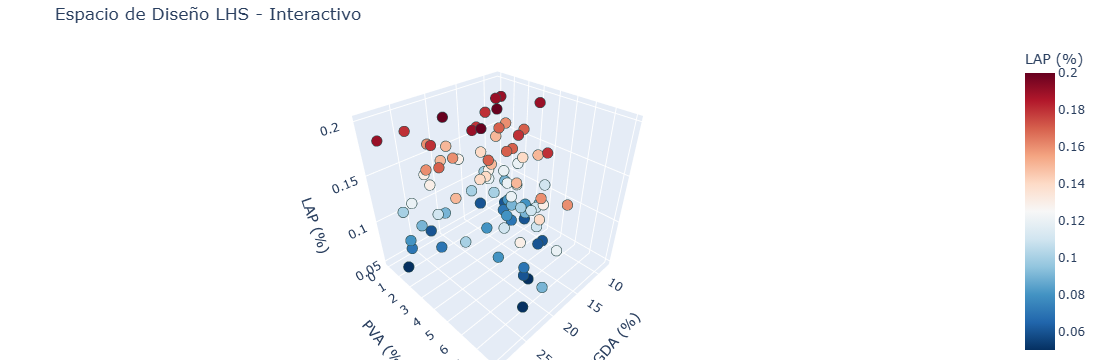

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats.qmc import LatinHypercube
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.drawing.image import Image as OpenpyxlImage
from io import BytesIO
import plotly.express as px
from IPython.display import display, HTML

# =====================================================================
# 1. GENERACIÓN DEL ESPACIO DE DISEÑO (LHS)
# =====================================================================

n_unique = 96
sampler = LatinHypercube(d=3, seed=42)
lhs_sample = sampler.random(n=n_unique)

lower_bounds = [10.0, 0.0, 0.05]
upper_bounds = [30.0, 0.3, 0.20]
scaled = lower_bounds + lhs_sample * (np.array(upper_bounds) - np.array(lower_bounds))

recetas = []
for i in range(n_unique):
    pol_tot = scaled[i][0]
    r_pva = scaled[i][1]
    lap = scaled[i][2]
    
    pva = int(round(pol_tot * r_pva, 0))
    pegda = int(round(pol_tot * (1 - r_pva), 0))
    lap_r = round(lap, 2)
    agua = round(100 - (pva + pegda + lap_r), 2)
    
    recetas.append({
        "ID_Receta": f"Formula_{i+1}",
        "PEGDA (%)": pegda,
        "PVA (%)": pva,
        "LAP (%)": lap_r,
        "Agua (%)": agua
    })

# =====================================================================
# 2. CREACIÓN DE LAS 3 PLACAS (288 POZOS EN TOTAL)
# =====================================================================

pozos_sbs = [f"{fila}{col}" for fila in "ABCDEFGH" for col in range(1, 13)]
lista_placas = []

for num_placa in range(1, 4):
    inicio = (num_placa - 1) * 32
    fin = num_placa * 32
    formulas_placa = recetas[inicio:fin]
    
    muestras = []
    for rep in [1, 2, 3]:
        for r in formulas_placa:
            rc = r.copy()
            rc["Placa"] = f"Placa_{num_placa}"
            rc["Repeticion"] = f"Rep_{rep}"
            muestras.append(rc)
            
    df_placa = pd.DataFrame(muestras)
    df_placa_random = df_placa.sample(frac=1, random_state=200+num_placa).reset_index(drop=True)
    df_placa_random.insert(1, "Pozo", pozos_sbs)
    lista_placas.append(df_placa_random)
    
df_maestro = pd.concat(lista_placas, ignore_index=True)
df_maestro = df_maestro[['Placa', 'Pozo', 'ID_Receta', 'Repeticion', 'PEGDA (%)', 'PVA (%)', 'LAP (%)', 'Agua (%)']]
df_unique = pd.DataFrame(recetas)

# =====================================================================
# 3. EXPORTACIÓN A EXCEL (Silenciosa, en segundo plano)
# =====================================================================
file_path = "Diseño_Opentrons_ASMI.xlsx"

# Generamos la imagen estática de matplotlib solo para pegarla en el Excel
fig_estatica = plt.figure(figsize=(9, 6))
ax_estatica = fig_estatica.add_subplot(111, projection='3d')
ax_estatica.scatter(df_unique['PEGDA (%)'], df_unique['PVA (%)'], df_unique['LAP (%)'],
                    c=df_unique['LAP (%)'], cmap='coolwarm', s=50, edgecolors='black')
ax_estatica.set_title('Espacio de Diseño LHS (96 Fórmulas Únicas)', fontweight='bold')
ax_estatica.set_xlabel('PEGDA (%)')
ax_estatica.set_ylabel('PVA (%)')
ax_estatica.set_zlabel('LAP (%)')
img_stream = BytesIO()
plt.savefig(img_stream, format='png', dpi=120)
plt.close(fig_estatica) # Cerramos la estática para que no moleste en el notebook

# Guardar en Excel
with pd.ExcelWriter(file_path, engine='openpyxl') as writer:
    df_maestro.to_excel(writer, sheet_name='Worklist_Opentrons', index=False)
    df_unique.to_excel(writer, sheet_name='Formulas_Unicas', index=False)

wb = openpyxl.load_workbook(file_path)
ws_vis = wb.create_sheet(title='Dashboard_Grafica', index=0)
img_stream.seek(0)
ws_vis.add_image(OpenpyxlImage(img_stream), 'B2')
wb.save(file_path)

# =====================================================================
# 4. VISUALIZACIÓN EN EL NOTEBOOK (TABLA MÓVIL Y GRÁFICA INTERACTIVA)
# =====================================================================

print(f"✅ Archivo Excel guardado en: {file_path}\n")

# A. Mostrar la tabla como un panel con Scroll (Tabla Móvil)
print("📌 Vista previa de la lista de trabajo (Scroll para ver más):")
tabla_html = f"""
<div style='max-height: 250px; overflow-y: auto; overflow-x: auto; border: 2px solid #002D56; border-radius: 5px; padding: 10px; margin-bottom: 20px;'>
    {df_maestro.to_html(classes='table table-striped', index=False, justify='center')}
</div>
"""
display(HTML(tabla_html))

# B. Mostrar la Gráfica 3D Móvil/Interactiva con Plotly
print("📌 Gráfica 3D Interactiva (Arrastra para rotar, pasa el ratón para ver datos):")
fig_interactiva = px.scatter_3d(df_unique, 
                                x='PEGDA (%)', 
                                y='PVA (%)', 
                                z='LAP (%)',
                                color='LAP (%)', 
                                hover_name='ID_Receta',
                                hover_data={'Agua (%)': True},
                                color_continuous_scale='RdBu_r',
                                title='Espacio de Diseño LHS - Interactivo')

fig_interactiva.update_traces(marker=dict(size=6, line=dict(width=1, color='DarkSlateGrey')))
fig_interactiva.update_layout(margin=dict(l=0, r=0, b=0, t=40))

# Desplegamos la gráfica 3D móvil en el notebook
fig_interactiva.show()